In [6]:
import numpy as np

def read_shse(file_path):
    with open(file_path, 'rb') as f:
        
        # --- HEADER ---
        datetime_bytes = f.read(14)
        datetime_str = datetime_bytes.decode(errors='ignore')

        fs = float(np.frombuffer(f.read(8), dtype=np.float64)[0])
        num_channels = int(np.frombuffer(f.read(1), dtype=np.uint8)[0])
        samples_per_channel = int(np.frombuffer(f.read(8), dtype=np.float64)[0])

        print("Datetime:", datetime_str)
        print("Sampling Rate:", fs)
        print("Channels:", num_channels)
        print("Samples per channel:", samples_per_channel)

        # --- DATA ---
        total_samples = samples_per_channel * num_channels
        data = np.fromfile(f, dtype=np.float64)

        # reshape
        data = data.reshape(-1, num_channels)

        # split channels
        channels = [data[:, i] for i in range(num_channels)]

        return fs, channels

In [7]:
file_path = r"F:\Pipeline Data\[2021] IT기반 고장진단\Data\0.3mm_Water_7Bar.shse"

fs, channels = read_shse(file_path)

ch1 = channels[0]
ch2 = channels[1]

print(len(ch1), len(ch2))

Datetime: 20180821114958
Sampling Rate: 1000000.0
Channels: 3
Samples per channel: 360000000
360000000 360000000


In [9]:
import numpy as np

def read_shse_header(file_path):
    with open(file_path, 'rb') as f:
        datetime_str = f.read(14).decode(errors='ignore')
        fs = float(np.frombuffer(f.read(8), dtype=np.float64)[0])
        num_channels = int(np.frombuffer(f.read(1), dtype=np.uint8)[0])
        samples_per_channel = int(np.frombuffer(f.read(8), dtype=np.float64)[0])

    return {
        "datetime": datetime_str,
        "fs": fs,
        "num_channels": num_channels,
        "samples_per_channel": samples_per_channel,
        "duration_sec": samples_per_channel / fs
    }

In [10]:
meta = read_shse_header(file_path)
meta

{'datetime': '20180821114958',
 'fs': 1000000.0,
 'num_channels': 3,
 'samples_per_channel': 360000000,
 'duration_sec': 360.0}

In [11]:
import numpy as np

def read_shse_time_window(file_path, start_sec=0, duration_sec=1):
    with open(file_path, 'rb') as f:
        # ----- header -----
        datetime_str = f.read(14).decode(errors='ignore')
        fs = float(np.frombuffer(f.read(8), dtype=np.float64)[0])
        num_channels = int(np.frombuffer(f.read(1), dtype=np.uint8)[0])
        samples_per_channel = int(np.frombuffer(f.read(8), dtype=np.float64)[0])

        samples_per_sec = int(fs)
        total_duration_sec = samples_per_channel // samples_per_sec

        if start_sec < 0 or start_sec >= total_duration_sec:
            raise ValueError("start_sec out of range")

        end_sec = min(start_sec + duration_sec, total_duration_sec)
        actual_duration = end_sec - start_sec

        # header size in bytes
        header_size = 14 + 8 + 1 + 8

        # each 1-second block contains all channels
        bytes_per_sample = 8
        block_size_bytes = num_channels * samples_per_sec * bytes_per_sample

        # move to desired second
        offset = header_size + start_sec * block_size_bytes
        f.seek(offset)

        channels = [[] for _ in range(num_channels)]

        for _ in range(actual_duration):
            for ch in range(num_channels):
                x = np.fromfile(f, dtype=np.float64, count=samples_per_sec)
                channels[ch].append(x)

        channels = [np.concatenate(ch_parts) for ch_parts in channels]
        t = np.arange(len(channels[0])) / fs + start_sec

        return {
            "datetime": datetime_str,
            "fs": fs,
            "num_channels": num_channels,
            "t": t,
            "channels": channels
        }

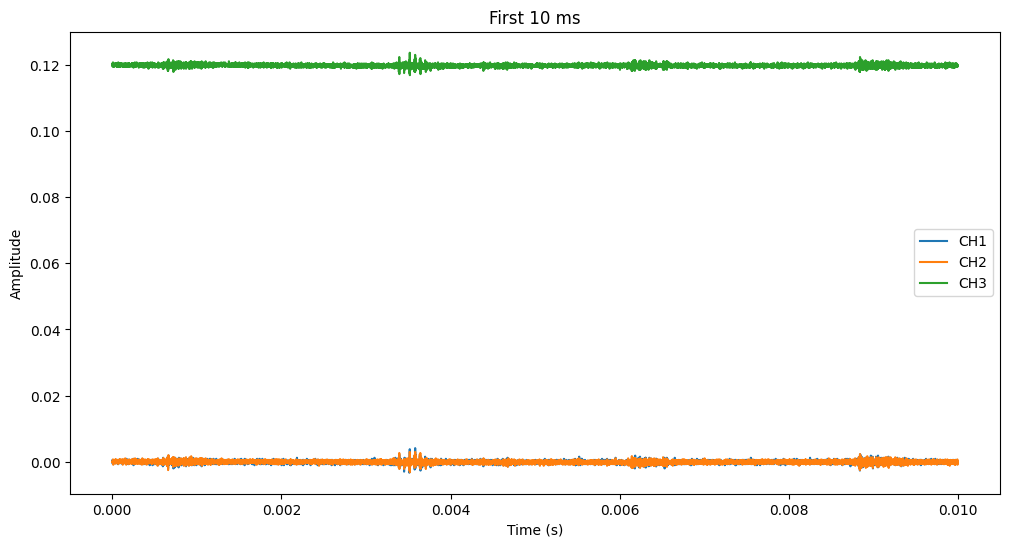

In [12]:
import matplotlib.pyplot as plt

data = read_shse_time_window(file_path, start_sec=0, duration_sec=1)

fs = data["fs"]
t = data["t"]
channels = data["channels"]

# only first 10 ms
n = int(0.01 * fs)

plt.figure(figsize=(12, 6))
for i, ch in enumerate(channels):
    plt.plot(t[:n], ch[:n], label=f'CH{i+1}')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("First 10 ms")
plt.show()

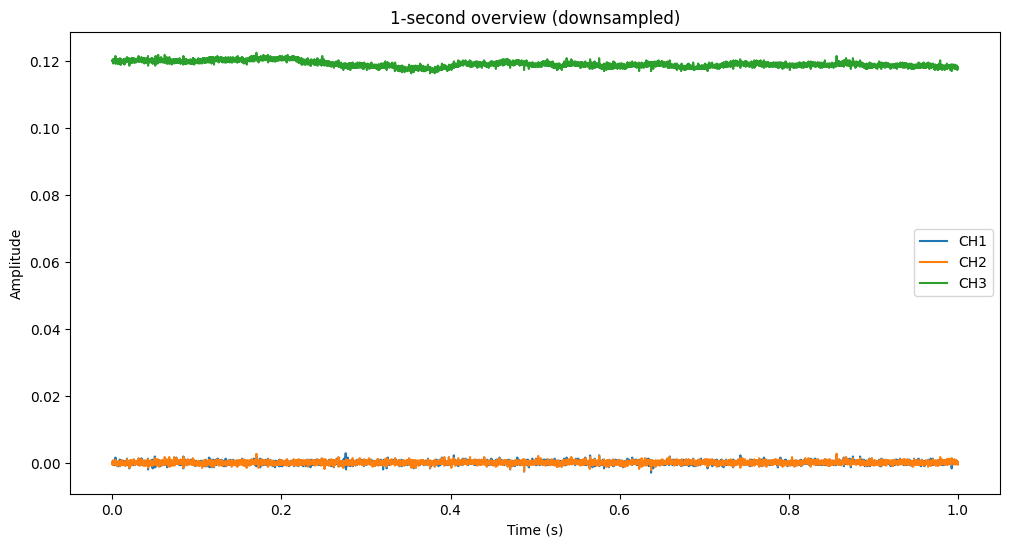

In [13]:
def downsample_for_plot(x, factor=100):
    return x[::factor]

data = read_shse_time_window(file_path, start_sec=0, duration_sec=1)

fs = data["fs"]
t = data["t"]
channels = data["channels"]

factor = 100
t_ds = t[::factor]

plt.figure(figsize=(12, 6))
for i, ch in enumerate(channels):
    plt.plot(t_ds, ch[::factor], label=f'CH{i+1}')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("1-second overview (downsampled)")
plt.show()

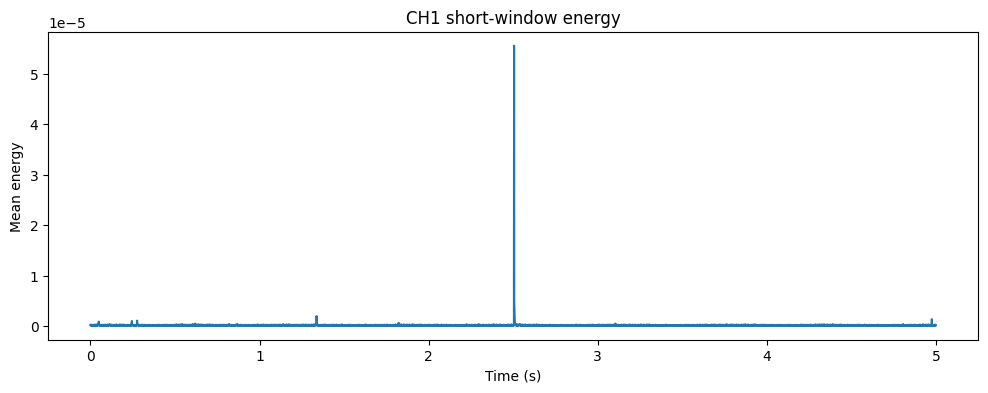

In [14]:
def window_energy(x, win):
    n = len(x) // win
    x = x[:n * win]
    return (x.reshape(n, win) ** 2).mean(axis=1)

data = read_shse_time_window(file_path, start_sec=0, duration_sec=5)

fs = data["fs"]
ch1 = data["channels"][0]

win = 1000  # 1000 samples = 1 ms at 1 MHz
e = window_energy(ch1, win)
t_e = np.arange(len(e)) * (win / fs)

plt.figure(figsize=(12, 4))
plt.plot(t_e, e)
plt.xlabel("Time (s)")
plt.ylabel("Mean energy")
plt.title("CH1 short-window energy")
plt.show()

In [15]:
from scipy.signal import hilbert
import numpy as np
import matplotlib.pyplot as plt

def detect_bursts(signal, fs, threshold_factor=5):
    # envelope
    envelope = np.abs(hilbert(signal))
    
    # noise estimate
    noise_level = np.median(envelope)
    
    threshold = threshold_factor * noise_level
    
    # detection mask
    bursts = envelope > threshold
    
    return envelope, bursts, threshold

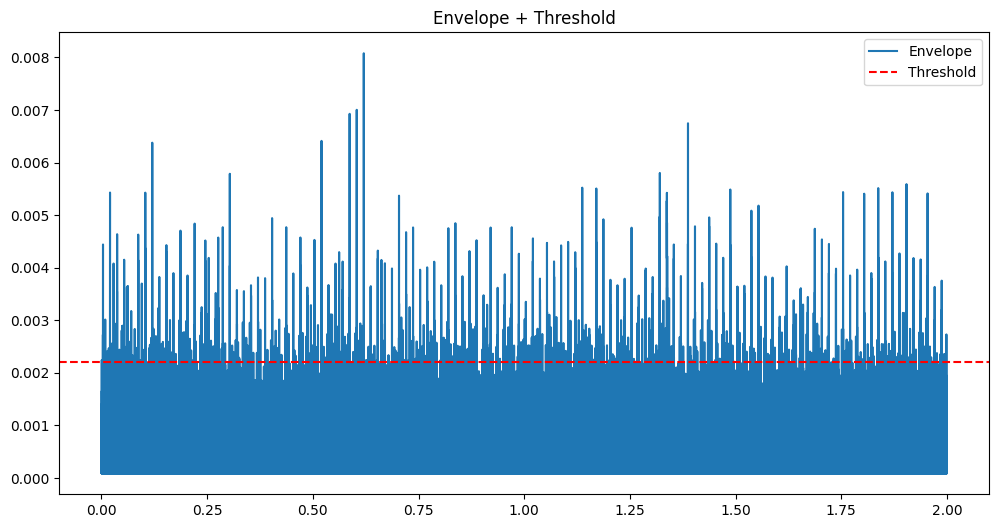

In [16]:
data = read_shse_time_window(file_path, start_sec=0, duration_sec=2)

fs = data["fs"]
t = data["t"]
ch1 = data["channels"][0]

env, bursts, th = detect_bursts(ch1, fs)

plt.figure(figsize=(12,6))
plt.plot(t, env, label='Envelope')
plt.axhline(th, color='r', linestyle='--', label='Threshold')
plt.title("Envelope + Threshold")
plt.legend()
plt.show()

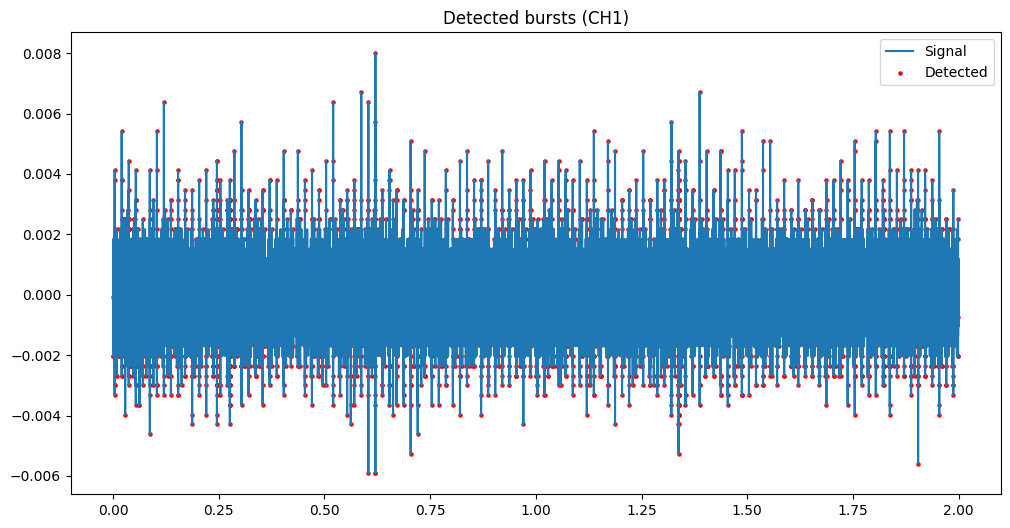

In [17]:
plt.figure(figsize=(12,6))
plt.plot(t, ch1, label='Signal')
plt.scatter(t[bursts], ch1[bursts], color='red', s=5, label='Detected')
plt.legend()
plt.title("Detected bursts (CH1)")
plt.show()

In [18]:
def compute_threshold(envelope, k=6):
    median = np.median(envelope)
    mad = np.median(np.abs(envelope - median))
    noise_std = 1.4826 * mad
    
    return median + k * noise_std

In [19]:
def detect_regions(envelope, threshold):
    mask = envelope > threshold
    
    regions = []
    start = None
    
    for i, val in enumerate(mask):
        if val and start is None:
            start = i
        elif not val and start is not None:
            end = i
            regions.append((start, end))
            start = None
    
    if start is not None:
        regions.append((start, len(mask)))
    
    return regions

In [20]:
def filter_regions(regions, min_length=50):
    return [r for r in regions if (r[1] - r[0]) >= min_length]

In [21]:
def extract_bursts(signal, regions):
    bursts = []
    
    for start, end in regions:
        segment = signal[start:end]
        peak = np.max(np.abs(segment))
        energy = np.sum(segment**2)
        center = (start + end) // 2
        
        bursts.append({
            "start": start,
            "end": end,
            "center": center,
            "peak": peak,
            "energy": energy
        })
    
    return bursts

In [22]:
env = np.abs(hilbert(ch1))
threshold = compute_threshold(env, k=6)

regions = detect_regions(env, threshold)
regions = filter_regions(regions, min_length=100)

bursts = extract_bursts(ch1, regions)

print("Detected bursts:", len(bursts))

Detected bursts: 0


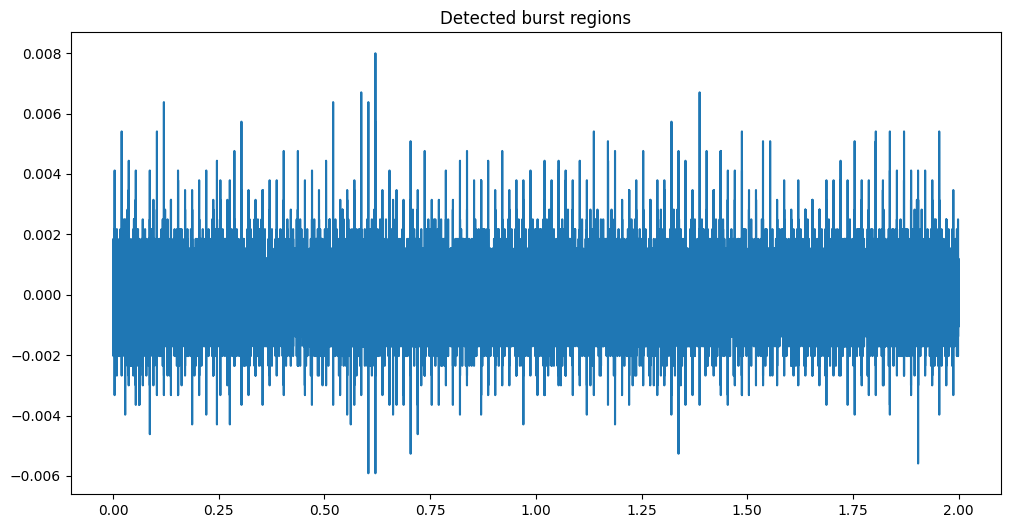

In [23]:
plt.figure(figsize=(12,6))
plt.plot(t, ch1, label='Signal')

for b in bursts:
    plt.axvspan(t[b["start"]], t[b["end"]], color='red', alpha=0.3)

plt.title("Detected burst regions")
plt.show()

In [24]:
from scipy.ndimage import uniform_filter1d

def smooth_envelope(envelope, win_size=200):
    return uniform_filter1d(envelope, size=win_size)

In [25]:
from scipy.ndimage import uniform_filter1d

def smooth_envelope(envelope, win_size=200):
    return uniform_filter1d(envelope, size=win_size)

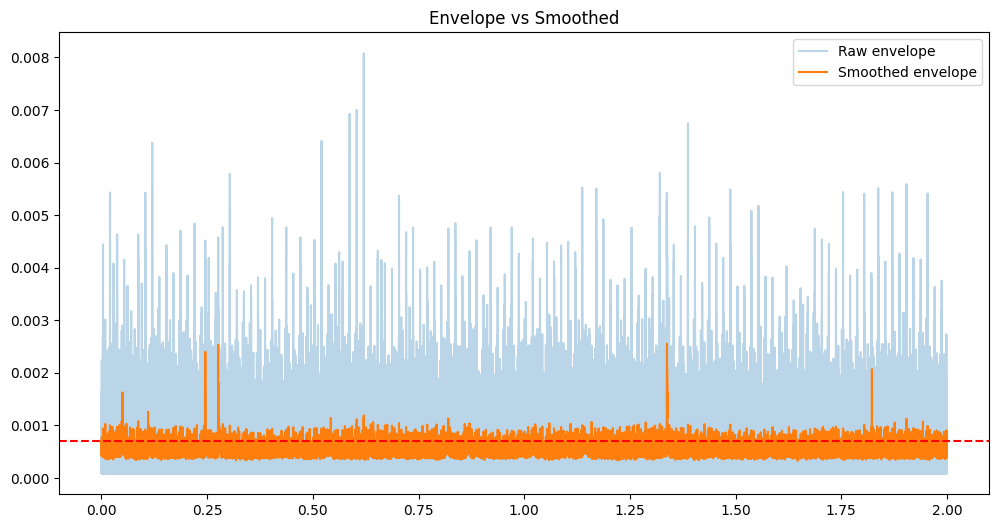

In [30]:
plt.figure(figsize=(12,6))
plt.plot(t, env, alpha=0.3, label='Raw envelope')
plt.plot(t, env_smooth, label='Smoothed envelope')
plt.axhline(threshold, color='r', linestyle='--')
plt.legend()
plt.title("Envelope vs Smoothed")
plt.show()

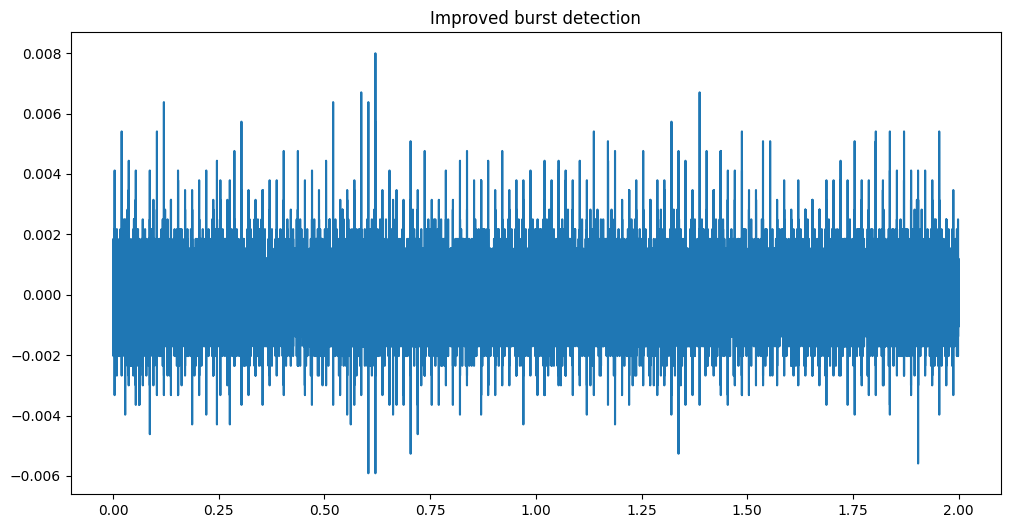

In [29]:
plt.figure(figsize=(12,6))
plt.plot(t, ch1)

for start, end in regions:
    plt.axvspan(t[start], t[end], color='red', alpha=0.3)

plt.title("Improved burst detection")
plt.show()

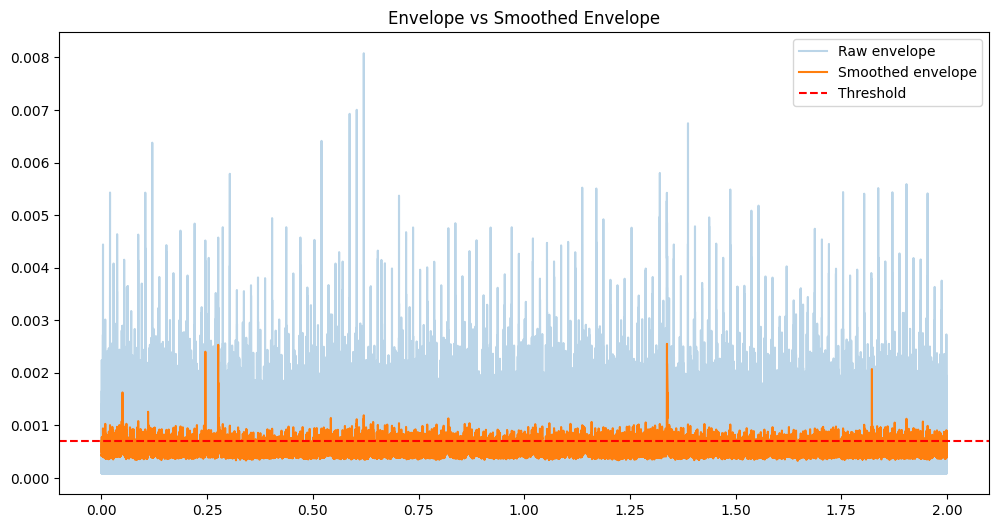

In [28]:
from scipy.signal import hilbert
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt

# Step 1: compute envelope
env = np.abs(hilbert(ch1))

# Step 2: smooth envelope
env_smooth = uniform_filter1d(env, size=200)

# Step 3: compute threshold on SMOOTHED envelope
threshold = compute_threshold(env_smooth, k=5)

# Step 4: plot
plt.figure(figsize=(12,6))
plt.plot(t, env, alpha=0.3, label='Raw envelope')
plt.plot(t, env_smooth, label='Smoothed envelope')
plt.axhline(threshold, color='r', linestyle='--', label='Threshold')
plt.legend()
plt.title("Envelope vs Smoothed Envelope")
plt.show()